In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")

In [3]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 22)

In [6]:
df.isnull().sum()

CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
LTV                 0
dtype: int64

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'LTV'],
      dtype='object')

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df.nunique()

CustomerID          7043
Gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
Tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
LTV                 6018
dtype: int64

**1. ANNUAL CHARGES**

In [10]:
df['AnnualCharges']=df['MonthlyCharges']*12

In [11]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV,AnnualCharges
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,358.2
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30,683.4
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70,646.2
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50,507.6
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40,848.4


**2.CREATED SERVICE COUNT COLUMN FOR COUNTING ADDITIONAL SERVICES CHOSEN BY CUSTOMER**

In [12]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [13]:
df["ServiceCount"] = (
    df[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

In [14]:
df["ServiceCount"].value_counts().sort_index()

ServiceCount
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [15]:
pd.crosstab(
    df["ServiceCount"],
    df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
ServiceCount,,
0,78.6,21.4
1,54.2,45.8
2,64.2,35.8
3,72.6,27.4
4,77.7,22.3
5,87.6,12.4
6,94.7,5.3


Insight: as the service count increases the churn rate decreases

In [16]:
df.to_csv(
    "../data/processed/telco_customer_churn_features.csv",
    index=False
)

**3. TENURE GROUP**

In [17]:
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

**4. IS MONTH TO MONTH**
( This feature identifies customers who are on month-to-month contracts.Month-to-month customers have a higher churn rate. )


In [18]:
df['IsMonthToMonth']=(df['Contract']=='Month-to-month').astype(int)

In [19]:
df[['IsMonthToMonth','Contract']].head(10)

,IsMonthToMonth,Contract
0,1,Month-to-month
1,0,One year
2,1,Month-to-month
3,0,One year
4,1,Month-to-month
5,1,Month-to-month
6,1,Month-to-month
7,1,Month-to-month
8,1,Month-to-month
9,0,One year


In [20]:
pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
TenureGroup,,
0-12 months,52.6,47.4
13-24 months,71.3,28.7
25-48 months,79.6,20.4
49-72 months,90.5,9.5


Insight: The longer customers stay, the less likely they are to churn.

In [21]:
pd.crosstab(df["IsMonthToMonth"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
IsMonthToMonth,,
0,93.2,6.8
1,57.3,42.7


Insight: Month to month customers have more churn rate than other contract type

**5. ADDED ELECTRONIC PAYMENT COUNTING COLUMN  (HIGH CHURN RATE FOR ELECTRONIC CHECK)**

In [22]:
df["IsElectronicPayment"] = (df["PaymentMethod"] == "Electronic check").astype(int)

In [23]:
pd.crosstab(
    df['IsElectronicPayment'],
    df['Churn'],
    normalize='index'
).round(3)*100

Churn,No,Yes
IsElectronicPayment,,
0,82.9,17.1
1,54.7,45.3


Customers using Electronic check have a much higher churn rate than customers using other payment methods.

**6. CREATED HAVE FAMILY OR NOT COLUMN**

In [24]:
df["HasFamily"] = (
    (df["Partner"] == "Yes") |
    (df["Dependents"] == "Yes")
).astype(int)

In [25]:
pd.crosstab(
    df['HasFamily'],
    df['Churn'],
    normalize='index'
).round(3)*100

Churn,No,Yes
HasFamily,,
0,65.8,34.2
1,80.2,19.8


Insight: customer with no family have high churn rate

In [26]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'LTV',
       'AnnualCharges', 'ServiceCount', 'TenureGroup', 'IsMonthToMonth',
       'IsElectronicPayment', 'HasFamily'],
      dtype='object')

In [27]:
df[[
    "ServiceCount",
    "IsElectronicPayment",
    "IsMonthToMonth",
    "HasFamily"
]].head()

,ServiceCount,IsElectronicPayment,IsMonthToMonth,HasFamily
0,1,1,1,1
1,2,0,0,0
2,2,0,1,0
3,3,0,0,0
4,0,1,1,0


In [28]:
#day 3 work


In [29]:
df.columns.tolist()

['CustomerID',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'LTV',
 'AnnualCharges',
 'ServiceCount',
 'TenureGroup',
 'IsMonthToMonth',
 'IsElectronicPayment',
 'HasFamily']

In [30]:
df.shape

(7043, 28)

In [31]:
df.isnull().sum().sum()

np.int64(0)

In [32]:
X = df.drop(columns=["CustomerID", "Churn", "LTV","TenureGroup"])
y = df["Churn"]

In [33]:
X.shape

(7043, 24)

In [34]:
y.shape

(7043,)

In [35]:
X.dtypes

Gender                  object
SeniorCitizen           object
Partner                 object
Dependents              object
Tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
AnnualCharges          float64
ServiceCount             int64
IsMonthToMonth           int64
IsElectronicPayment      int64
HasFamily                int64
dtype: object

**ENCODING CATEGORICAL COLUMN FOR ML**

In [36]:
categorical_cols = X.select_dtypes(include=["object","string"]).columns.tolist()
categorical_cols

['Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

**CONVERTING THESE TO NUMBERS**

In [37]:
X_encoded=pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
'''
if the Contract column have 3 values,only 2 columns are created instead of 3(one year and two year).
so if both of them are 0 that means it is month to month
'''

'\nif the Contract column have 3 values,only 2 columns are created instead of 3(one year and two year).\nso if both of them are 0 that means it is month to month\n'

In [38]:
X_encoded.shape

(7043, 35)

In [39]:
X_encoded.head()

,Tenure,MonthlyCharges,TotalCharges,AnnualCharges,ServiceCount,IsMonthToMonth,IsElectronicPayment,HasFamily,Gender_Male,SeniorCitizen_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,358.2,1,1,1,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,683.4,2,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,646.2,2,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,507.6,3,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,848.4,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [40]:
X_encoded.dtypes

Tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
AnnualCharges                            float64
ServiceCount                               int64
IsMonthToMonth                             int64
IsElectronicPayment                        int64
HasFamily                                  int64
Gender_Male                                int64
SeniorCitizen_Yes                          int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes    

In [41]:
X_encoded.shape

(7043, 35)

In [42]:
X_encoded.isnull().sum().sum()

np.int64(0)

In [43]:
#checking data types are numeric
X_encoded.dtypes.value_counts()

int64      32
float64     3
Name: count, dtype: int64

**--------------------TRAIN / TEST SPLIT-------------------------**

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,# 20 % for testing
    random_state=42,
    stratify=y #train and test sets keep roughly the same proportion of churn and non-churn customers as the original dataset.
)

In [45]:
X_train.shape

(5634, 35)

In [46]:
X_test.shape

(1409, 35)

In [47]:
y_train.shape

(5634,)

In [48]:
y_test.shape

(1409,)

### Checking Churn Distribution After Train/Test Split

In [49]:
print("Overall churn proportion:")
print(y.value_counts(normalize=True))

print("\nTraining churn proportion:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn proportion:")
print(y_test.value_counts(normalize=True))

Overall churn proportion:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Training churn proportion:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

Testing churn proportion:
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


### Feature Scaling 
putting all features on a similar numerical scale so that differences in their original ranges don't unfairly affect the ML model.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (5634, 35)
X_test_scaled shape: (1409, 35)


### Logistic Regression
creating our first churn classification model and training it using the scaled training data.

In [52]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

* [X] Logical Regression training is done
* model learned that there are 2 possible outcomes: No churn and Yes churn
* model received all 35 features
* model needed 38 iterations to finish learning

### Logistic Regression Predictions

In [53]:
y_pred_log = log_model.predict(X_test_scaled)

print(y_pred_log[:10]) #prediction for first 10 test customers

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No']


* need to check whether this predictions are correct.
- Precision → Of the customers we predicted would churn, how many actually churned?
- Recall → Of the customers who actually churned, how many did we correctly identify?
- F1-score → A balance between Precision and Recall.

### Logistic Regression Evaluation

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_log = precision_score(y_test, y_pred_log, pos_label="Yes")
recall_log = recall_score(y_test, y_pred_log, pos_label="Yes")
f1_log = f1_score(y_test, y_pred_log, pos_label="Yes")

print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-score:", f1_log)

Precision: 0.6614420062695925
Recall: 0.5641711229946524
F1-score: 0.6089466089466089


- When model predicts churn, ~66% actually churn
- catches ~56% of the customers who actually churn

### Random Forest
type of model that can capture more complex relationships between customer features than Logistic Regression.

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

 - [X] random forest training is done

### Random Forest Prediction

In [56]:
y_pred_rf = rf_model.predict(X_test_scaled)

print(y_pred_rf[:10])

['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No']


### Random Forest Evaluation

In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_test, y_pred_rf, pos_label="Yes")
recall_rf = recall_score(y_test, y_pred_rf, pos_label="Yes")
f1_rf = f1_score(y_test, y_pred_rf, pos_label="Yes")

print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Precision: 0.6413793103448275
Recall: 0.49732620320855614
F1-score: 0.5602409638554217


### XGBoost

In [58]:
#converting  yes and no to 1 and 0 inorder to predict for the xgboost
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

In [59]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_scaled, y_train_xgb)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


- [X] XGBoost training is done

### XGBoost Prediction

In [60]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(y_pred_xgb[:10])

[0 1 0 0 0 1 0 0 0 0]


### XGBoost Evaluation

In [61]:
precision_xgb = precision_score(y_test_xgb, y_pred_xgb, pos_label=1)
recall_xgb = recall_score(y_test_xgb, y_pred_xgb, pos_label=1)
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, pos_label=1)

print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)

Precision: 0.6474576271186441
Recall: 0.5106951871657754
F1-score: 0.5710014947683109


### Model Comparison

| Model | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Logistic Regression | 66.14% | 56.42% | 60.89% |
| Random Forest | 62.33% | 50.00% | 55.49% |
| XGBoost | 64.75% | 51.07% | 57.10% |

### Model Selection

**Logistic Regression** achieved the highest F1-score (60.89%) among the three models, with a precision of 66.14% and recall of 56.42%. Therefore, Logistic Regression is the best-performing model based on the current test-set results.

### SHAP 
Helps to know which features influenced in the model predictions the most

### SHAP Explainability

In [62]:
import shap
explainer = shap.LinearExplainer(
    log_model,
    X_train_scaled
)

shap_values = explainer.shap_values(X_test_scaled)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


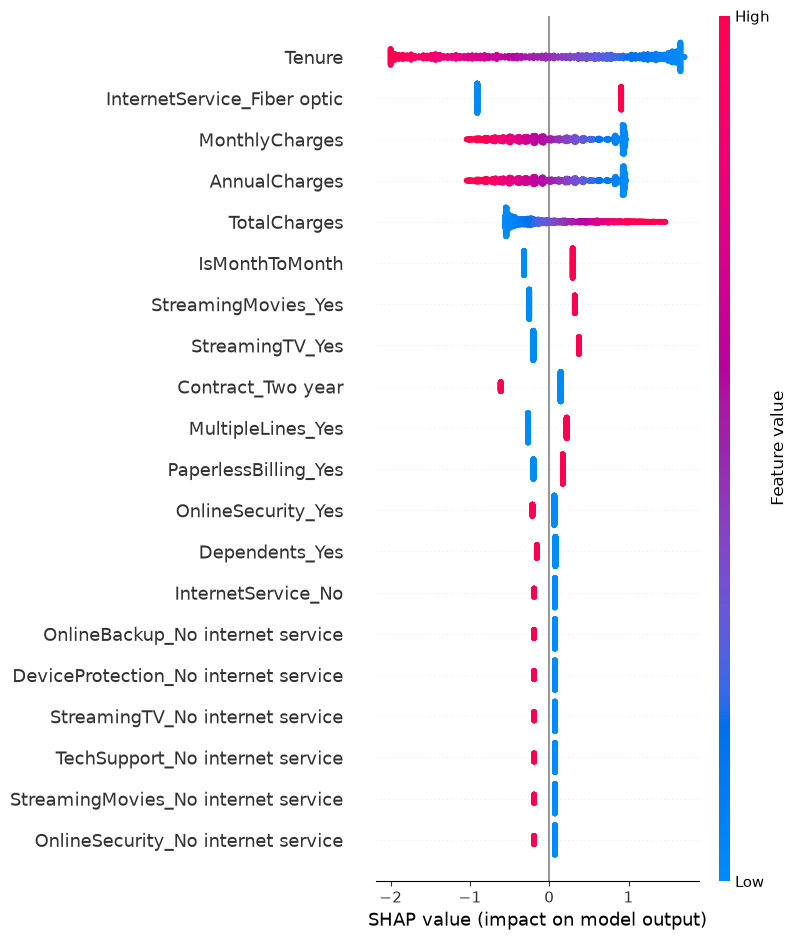

In [63]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_encoded.columns
)

### SHAP Interpretation

The SHAP analysis shows that Tenure, Internet Service, Monthly Charges,
Annual Charges, Total Charges, and Contract type are among the most
influential features in the Logistic Regression model.

* Tenure is the most influential feature. Higher tenure generally pushes
predictions toward No Churn, while lower tenure tends to push predictions
toward Churn.

* Having a two-year contract tends to push predictions toward No Churn.
.